In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
defective_path = r"C:\Users\DAKSH KATHURIA\OneDrive\Desktop\IAIML\Experiment - 4\dataset\defective"
non_defective_path = r"C:\Users\DAKSH KATHURIA\OneDrive\Desktop\IAIML\Experiment - 4\dataset\non defective"

In [3]:
defective_images = os.listdir(defective_path)
non_defective_images = os.listdir(non_defective_path)

print("Defective images:", len(defective_images))
print("Non-defective images:", len(non_defective_images))

Defective images: 695
Non-defective images: 273


In [4]:
print(defective_images[:10])
print(non_defective_images[:10])

['damaged_100_jpg.rf.ffaa34210081bbe55929e3df2b9f07be.jpg', 'damaged_101_jpg.rf.2b3ac5937c77af2a8961828288b33ac7.jpg', 'damaged_102_jpg.rf.d4ff31341a8b8c7f82dce010059a8f21.jpg', 'damaged_103_jpg.rf.3088231f59350156b56d081432779f92.jpg', 'damaged_104_jpg.rf.8df2e1bef498b6edc986e9e3c441950e.jpg', 'damaged_105_jpg.rf.071abdb3c045ab9e86456d274c726143.jpg', 'damaged_106_jpg.rf.dabd9c0f268be5e07b94058396f1706f.jpg', 'damaged_107_jpg.rf.c63a5a8fdb6ded0600236b363fcb9cc7.jpg', 'damaged_108_jpg.rf.ecc5bcd109d63297b4528502bedbe7f8.jpg', 'damaged_109_jpg.rf.bf41a111112187bbdd50345b58cdcdff.jpg']
['IMG_0035_jpeg.rf.3822881e52fce614fb800cf96560b411.jpg', 'IMG_0050_jpeg.rf.3080104bcb699bd6c04ef70ec84aa843.jpg', 'IMG_0190_jpeg.rf.f9cfe8468247509688540cc09e536724.jpg', 'IMG_0235_jpeg.rf.e877ac1ff7910c4eeed2d49a01b45a05.jpg', 'IMG_0258_jpeg.rf.6767556b78caaba30af6dbcc6bc77441.jpg', 'IMG_0294_jpeg.rf.1be665dc3bb424da3df43c17a70c60f4.jpg', 'IMG_0342_jpeg.rf.1a77abbb3cefbfedc01c9bd154b02bed.jpg', 'IMG_0362

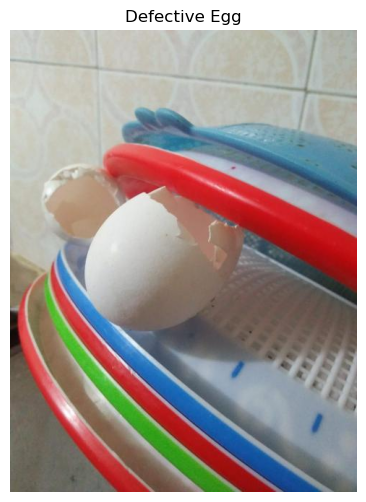

In [5]:
image_path = os.path.join(defective_path, defective_images[0])
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title("Defective Egg")
plt.axis("off")
plt.show()

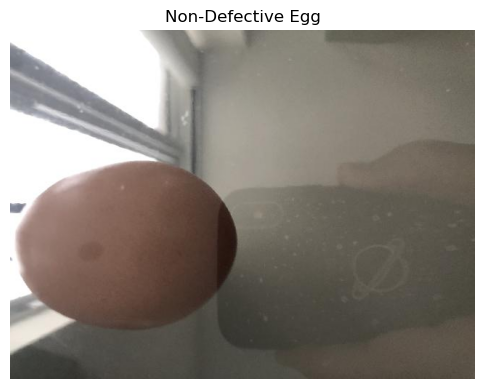

In [6]:
image_path = os.path.join(non_defective_path, non_defective_images[0])
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title("Non-Defective Egg")
plt.axis("off")
plt.show()


In [7]:
img1 = cv2.imread(os.path.join(defective_path, defective_images[0]))
img2 = cv2.imread(os.path.join(non_defective_path, non_defective_images[0]))
print("Defective image shape:", img1.shape)
print("Non-defective image shape:", img2.shape)

Defective image shape: (640, 480, 3)
Non-defective image shape: (480, 640, 3)


In [8]:
dimensions = {}

for image_name in defective_images:
    path = os.path.join(defective_path, image_name)
    image = cv2.imread(path)

    if image is not None:
        shape = image.shape
        dimensions[shape] = dimensions.get(shape, 0) + 1

for image_name in non_defective_images:
    path = os.path.join(non_defective_path, image_name)
    image = cv2.imread(path)

    if image is not None:
        shape = image.shape
        dimensions[shape] = dimensions.get(shape, 0) + 1

print("Different dimensions found:\n")

for shape, count in dimensions.items():
    print(shape, "→", count, "images")

Different dimensions found:

(640, 480, 3) → 942 images
(480, 640, 3) → 26 images


In [9]:
image_name = defective_images[0]
image_path = os.path.join(defective_path, image_name)
image = cv2.imread(image_path)

print("Minimum pixel value:", image.min())
print("Maximum pixel value:", image.max())
print("Mean pixel value:", image.mean())

Minimum pixel value: 2
Maximum pixel value: 255
Mean pixel value: 139.79021592881944


In [10]:
# STEP 6 — Resize images while preserving aspect ratio

IMG_SIZE = 224

def resize_with_padding(image, size=224):
    h, w = image.shape[:2]
    scale = min(size / w, size / h)
    new_w = int(w * scale)
    new_h = int(h * scale)
    resized = cv2.resize(image, (new_w, new_h))
    canvas = np.zeros((size, size, 3), dtype=np.uint8)

    x_offset = (size - new_w) // 2
    y_offset = (size - new_h) // 2
    canvas[y_offset:y_offset + new_h,
           x_offset:x_offset + new_w] = resized

    return canvas

In [11]:
image_name = defective_images[0]
image_path = os.path.join(defective_path, image_name)

image = cv2.imread(image_path)

resized_image = resize_with_padding(image)

print("Original shape:", image.shape)
print("Resized shape:", resized_image.shape)

Original shape: (640, 480, 3)
Resized shape: (224, 224, 3)


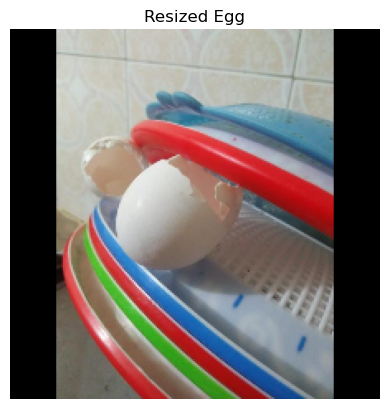

In [12]:
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
plt.title("Resized Egg")
plt.axis("off")
plt.show()

In [13]:
# STEP 7 — Convert image to grayscale

gray_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)

print("Original shape:", resized_image.shape)
print("Grayscale shape:", gray_image.shape)

Original shape: (224, 224, 3)
Grayscale shape: (224, 224)


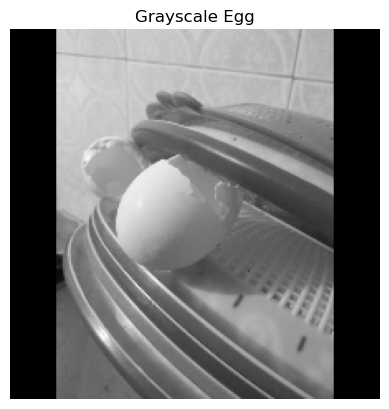

In [14]:
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Egg")
plt.axis("off")
plt.show()

In [15]:
# STEP 8 — Normalize pixel values

normalized_image = gray_image / 255.0

print("Minimum value:", normalized_image.min())
print("Maximum value:", normalized_image.max())
print("Mean value:", normalized_image.mean())

Minimum value: 0.0
Maximum value: 0.9882352941176471
Mean value: 0.41164598651960776


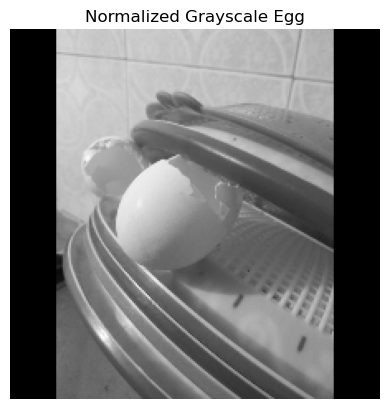

In [16]:
plt.imshow(normalized_image, cmap="gray")
plt.title("Normalized Grayscale Egg")
plt.axis("off")
plt.show()

In [17]:
# STEP 9 — Noise reduction

denoised_image = cv2.GaussianBlur(normalized_image, (5, 5), 0)

print("Original shape:", normalized_image.shape)
print("Denoised shape:", denoised_image.shape)

Original shape: (224, 224)
Denoised shape: (224, 224)


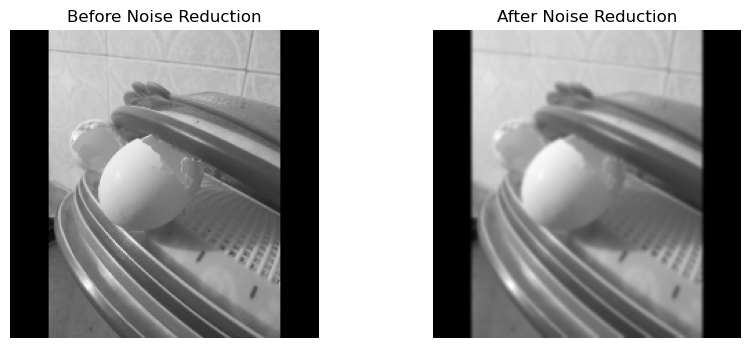

In [18]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(normalized_image, cmap="gray")
plt.title("Before Noise Reduction")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(denoised_image, cmap="gray")
plt.title("After Noise Reduction")
plt.axis("off")

plt.show()